In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../time_series_analysis/intro_to_time_series/bitcoin_price.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


Time series index

In [3]:
#Convert date column to datetime and set as index
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")
df.set_index("Date", inplace=True)
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [4]:
# select the bitcoin data from november 2021
df.loc["2021-11-09"]

Open         6.754973e+04
High         6.853034e+04
Low          6.638206e+04
Close        6.697183e+04
Adj Close    6.697183e+04
Volume       4.235799e+10
Name: 2021-11-09 00:00:00, dtype: float64

In [5]:
# loading the data and setting the index
df1 = pd.read_csv("../time_series_analysis/intro_to_time_series/bitcoin_price.csv", parse_dates=True, index_col="Date")
df1.index

DatetimeIndex(['2014-09-17', '2014-09-18', '2014-09-19', '2014-09-20',
               '2014-09-21', '2014-09-22', '2014-09-23', '2014-09-24',
               '2014-09-25', '2014-09-26',
               ...
               '2023-12-21', '2023-12-22', '2023-12-23', '2023-12-24',
               '2023-12-25', '2023-12-26', '2023-12-27', '2023-12-28',
               '2023-12-29', '2023-12-30'],
              dtype='datetime64[ns]', name='Date', length=3392, freq=None)

In [6]:
#resample the data to monthly frequency and take the mean
df.resample("M").mean()



C:\Users\msi\AppData\Local\Temp\ipykernel_6864\2246409169.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample("M").mean()


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-30,412.654003,421.104422,398.174641,407.182428,407.182428,2.934864e+07
2014-10-31,365.748000,374.314260,354.856645,364.148873,364.148873,2.912885e+07
2014-11-30,364.850235,376.494235,357.241831,366.099799,366.099799,2.199111e+07
2014-12-31,343.074836,347.487129,336.565775,341.267871,341.267871,1.784201e+07
2015-01-31,251.799905,261.391583,240.495550,248.782547,248.782547,3.544555e+07
...,...,...,...,...,...,...
2023-08-31,27959.756615,28204.527722,27517.854587,27852.792843,27852.792843,1.412013e+10
2023-09-30,26271.268229,26573.941862,26041.182292,26306.136393,26306.136393,1.125458e+10
2023-10-31,29511.811114,30155.900454,29235.543977,29755.895161,29755.895161,1.536857e+10


Text(0.5, 1.0, 'Bitcoin Closing Price and 7-Day Rolling Average')

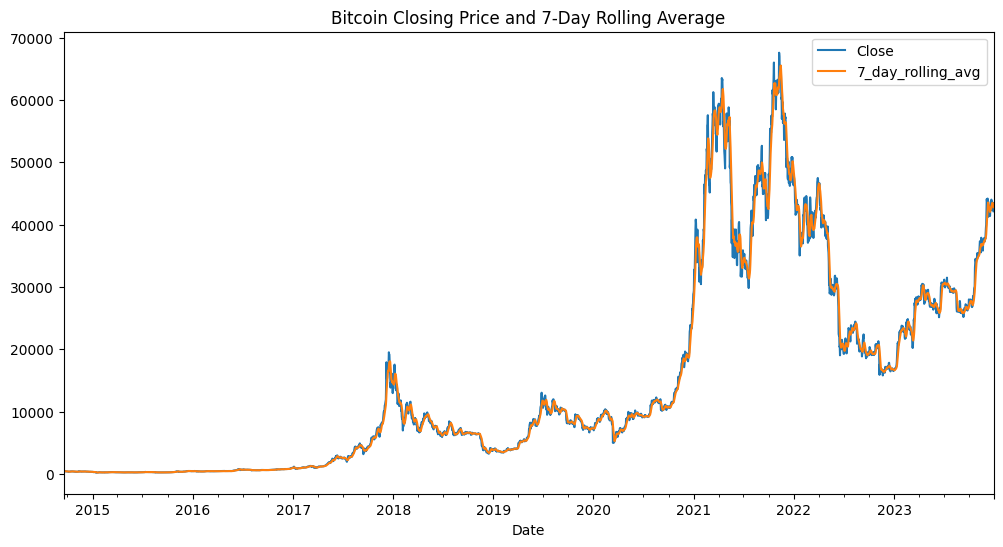

In [7]:
#7-day rolling average of the closing price
df['7_day_rolling_avg'] = df['Close'].rolling(window=7).mean()
df[['Close', '7_day_rolling_avg']].plot(figsize=(12, 6))
plt.title('Bitcoin Closing Price and 7-Day Rolling Average')

In [8]:
# Find out the highest average month
df.resample("M").mean().sort_values("Close", ascending=False).head(1)

C:\Users\msi\AppData\Local\Temp\ipykernel_6864\1903918380.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample("M").mean().sort_values("Close", ascending=False).head(1)


,Open,High,Low,Close,Adj Close,Volume,7_day_rolling_avg
Date,,,,,,,
2021-11-30,60857.520312,62046.720703,59290.196615,60621.488802,60621.488802,3.510901e+10,61081.232031


In [9]:
#calculate daily returns- price of today/price of yesterday -1
df['Daily_Return'] = df['Close'].pct_change()*100

In [10]:
volatility = df['Daily_Return'].std()
print(f"Volatility of Bitcoin Daily Returns: {volatility:.2f}%")

Volatility of Bitcoin Daily Returns: 3.70%


In [11]:
# days with more then 10% daily return
df[abs(df['Daily_Return']) > 10].head()

,Open,High,Low,Close,Adj Close,Volume,7_day_rolling_avg,Daily_Return
Date,,,,,,,,
2014-11-12,367.984985,429.717987,367.984985,423.561005,423.561005,45783200,365.519579,15.193570
2015-01-03,314.846008,315.149994,281.082001,281.082001,281.082001,33054400,310.171718,-10.776686
2015-01-13,267.394012,268.277008,219.906006,225.860992,225.860992,72843904,271.743853,-15.659308
2015-01-14,223.893997,223.893997,171.509995,178.102997,178.102997,97638704,255.138994,-21.144862
2015-01-15,176.897003,229.067001,176.897003,209.843994,209.843994,81773504,244.638280,17.821709


# Data Visulaization

Text(0.5, 1.0, 'Bitcoin Daily Closing Price')

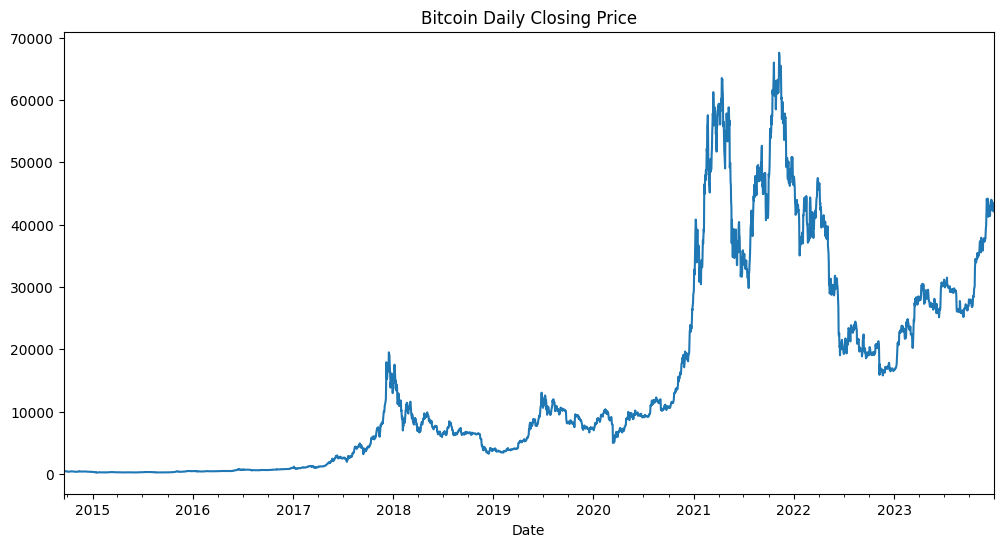

In [12]:
# Daily closing price plot
df['Close'].plot(figsize=(12, 6))
plt.title('Bitcoin Daily Closing Price')

C:\Users\msi\AppData\Local\Temp\ipykernel_6864\3103469869.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df['Volume'].resample('Y').sum().plot()


Text(0.5, 1.0, 'Yearly Volume of Bitcoin')

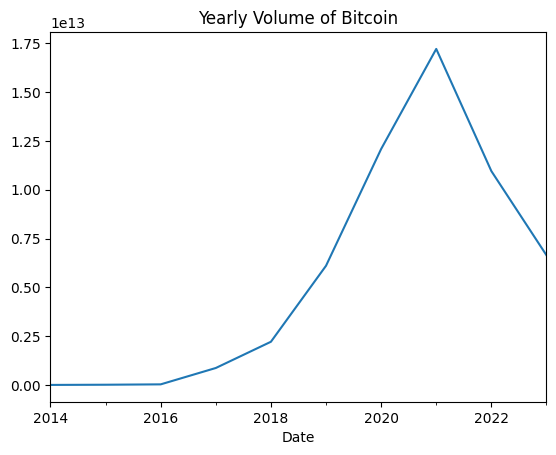

In [14]:
# Plot the Yearly volume of bitcoin
df['Volume'].resample('Y').sum().plot()
plt.title('Yearly Volume of Bitcoin')

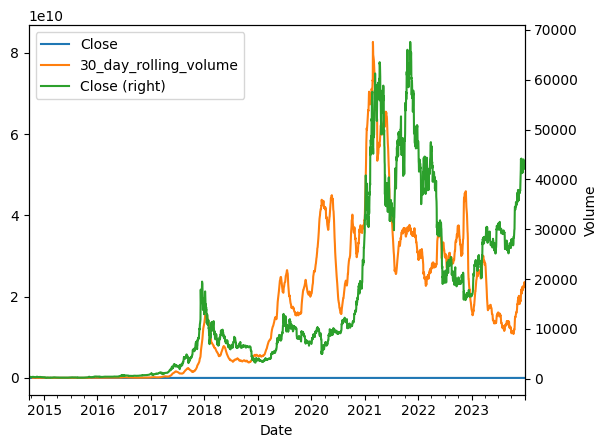

In [15]:
#Plotting Closing Price and 30 day rolling Volume
df['30_day_rolling_volume'] = df['Volume'].rolling(window=30).mean()
df[['Close', '30_day_rolling_volume']].plot(legend=True)
ax = df['Close'].plot(secondary_y=True, legend=True)
ax.set_ylabel('Volume')
plt.show()

this says whenever the prices goes down, traders trade in high colume

In [19]:
# Correlation btw the 30 day rolling volume and the closing price
df[['Close', '30_day_rolling_volume']].corr()

,Close,30_day_rolling_volume
Close,1.000000,0.750445
30_day_rolling_volume,0.750445,1.000000


# Data Manipulation

In [22]:
# identify missing values
df.isnull().sum()

# Drop missing values
df.dropna(inplace=True)


In [25]:
# Extract time variables
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday

df['is_weekend'] = df.index.weekday > 4

df.head()

,Open,High,Low,Close,Adj Close,Volume,7_day_rolling_avg,Daily_Return,30_day_rolling_volume,Year,Month,Day,weekday,weekday_num,is_weekend
Date,,,,,,,,,,,,,,,
2014-10-16,394.518005,398.807007,373.070007,382.556000,382.556000,26990000,381.574720,-3.094692,3.624856e+07,2014,10,16,Thursday,3,False
2014-10-17,382.756012,385.477997,375.389008,383.757996,383.757996,13600700,384.745575,0.314201,3.600002e+07,2014,10,17,Friday,4,False
2014-10-18,383.976013,395.157990,378.971008,391.441986,391.441986,11416800,388.908857,2.002301,3.523114e+07,2014,10,18,Saturday,5,True
2014-10-19,391.253998,393.938995,386.457001,389.545990,389.545990,5914570,390.479854,-0.484362,3.416430e+07,2014,10,19,Sunday,6,True
2014-10-20,389.230988,390.084015,378.252014,382.845001,382.845001,16419000,389.398568,-1.720205,3.348282e+07,2014,10,20,Monday,0,False


In [26]:
#Feature engineering - Lagged values( past values of the target variable used as features)
df['Close_Lag_1'] = df['Close'].shift(1)
df['Close_Lag_7'] = df['Close'].shift(2)

Seasonal Decomposition
- identifies the trend, seasonality and error term

# Seasonality

In [27]:
# Seasonality
from statsmodels.graphics.tsaplots import month_plot, quarter_plot

C:\Users\msi\AppData\Local\Temp\ipykernel_6864\462400997.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_plot(df['Close'].resample('M').mean(),


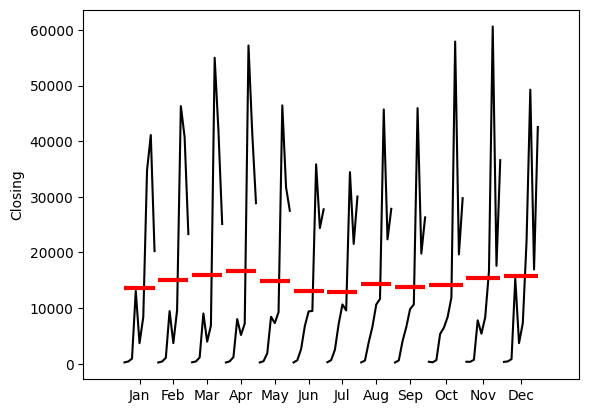

In [32]:
#Plotting the monthly seasonality
month_plot(df['Close'].resample('M').mean(),
           ylabel = 'Closing')
plt.show()

C:\Users\msi\AppData\Local\Temp\ipykernel_6864\3604540593.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarter_plot(df['Close'].resample('Q').mean(),


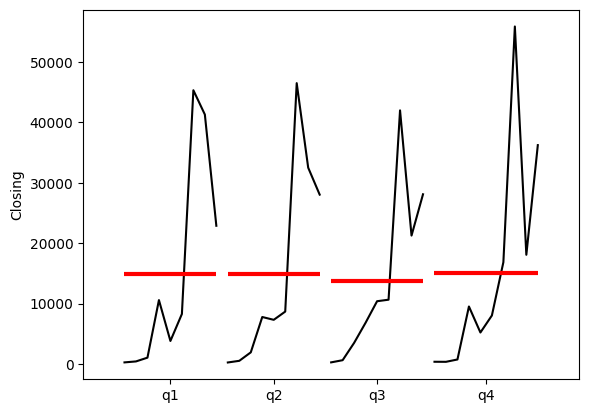

In [33]:
#Plotting the quaterly seasonality
quarter_plot(df['Close'].resample('Q').mean(),
             ylabel = 'Closing')
plt.show()

In [39]:
#load new data
df_choco = pd.read_csv("../time_series_analysis/intro_to_time_series/choco_monthly_revenue.csv", index_col=0, parse_dates=True)
df_choco.head()

,revenue
Month with Year,
2018-01-01,1458
2018-02-01,1102
2018-03-01,1584
2018-04-01,1676
2018-05-01,1461


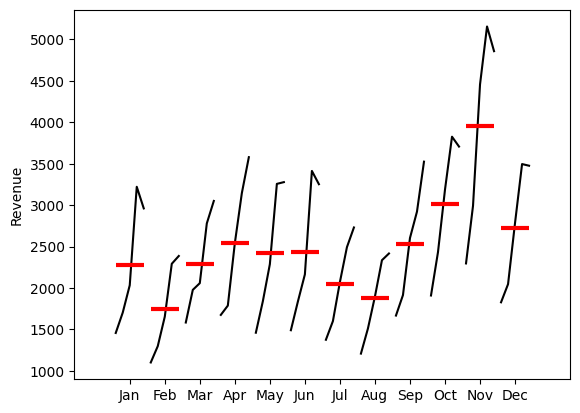

In [41]:
#Plotting the monthly seasonality
month_plot(df_choco['revenue'],
           ylabel = 'Revenue')
plt.show()